In [23]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [24]:
# Loading dataset
df = pd.read_csv("merged ai and job market.csv")

In [25]:
# Removing missign or 'unknown' skills 
df = df[df["skills_standardized"].notna()]
df = df[df["skills_standardized"] != "unknown"]

In [26]:
# Splitting skills into a list
df["skills_list"] = df["skills_standardized"].apply(lambda x: x.split(";"))

# Frequency analysis
all_skills = [skill for sublist in df["skills_list"] for skill in sublist]

# Count frequency
skill_counts = pd.Series(all_skills).value_counts()

# Get unique skills
unique_skills = set(all_skills)
print("Total unique skills:", len(unique_skills))
print(sorted(unique_skills))

Total unique skills: 9
['cloud_computing', 'data_engineering', 'data_visualization', 'deep_learning', 'machine_learning', 'nlp', 'python', 'sql', 'statistics']


In [27]:
# Top N skills
top_n = 5
top_skills = skill_counts.head(top_n)

print("Top Skills:\n", top_skills)

Top Skills:
 cloud_computing     5897
python              5625
machine_learning    5521
sql                 5372
deep_learning       5206
Name: count, dtype: int64


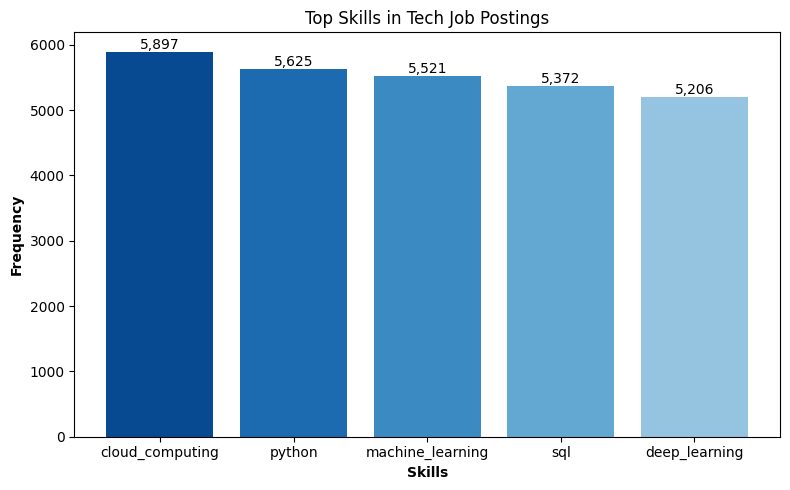

In [28]:
# Visualization
top_n = 5
top_skills = skill_counts.head(top_n)

plt.figure(figsize=(8,5))

# Create gradient colors
colors = cm.Blues(np.linspace(0.9, 0.4, len(top_skills)))

bars = plt.bar(top_skills.index, top_skills.values, color=colors)

# Add labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height,                             
        f"{int(height):,}",                 
        ha='center',
        va='bottom'
    )

plt.xlabel("Skills", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.title("Top Skills in Tech Job Postings")

plt.tight_layout()
plt.show()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
# TF-IDF for recommendation system
df["skills_text"] = df["skills_list"].apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df["skills_text"])

# Encode experience
experience_map = {"entry": 0, "mid": 1, "senior": 2}
df["experience_encoded"] = df["experience"].map(experience_map)

# Drop missing values
df = df.dropna(subset=["experience_encoded"])

# One-hot encode categorical features
df_encoded = pd.get_dummies(df[["remote_type", "location"]])

# Align indices
df_encoded = df_encoded.loc[df.index]

---

In [31]:
# Build feature matrix
X = np.hstack([
    tfidf_matrix.toarray(),
    df["experience_encoded"].values.reshape(-1, 1),
    df_encoded.values
])

y = df["salary_usd"].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10866, 199)
y shape: (10866, 1)


In [32]:
# Scaling target
from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

In [33]:
from sklearn.model_selection import train_test_split

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_scaled, test_size=0.2, random_state=42
)

In [34]:
# Pytorch setup
import torch
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [35]:
# Model
class SalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(SalaryModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

model = SalaryModel(X_train.shape[1])


In [37]:
# Train
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200

for epoch in range(epochs):
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.4125
Epoch 20, Loss: 0.4117
Epoch 30, Loss: 0.4058
Epoch 40, Loss: 0.4030
Epoch 50, Loss: 0.4024
Epoch 60, Loss: 0.3978
Epoch 70, Loss: 0.3965
Epoch 80, Loss: 0.3969
Epoch 90, Loss: 0.3921
Epoch 100, Loss: 0.3905
Epoch 110, Loss: 0.3875
Epoch 120, Loss: 0.3883
Epoch 130, Loss: 0.3856
Epoch 140, Loss: 0.3849
Epoch 150, Loss: 0.3832
Epoch 160, Loss: 0.3841
Epoch 170, Loss: 0.3838
Epoch 180, Loss: 0.3835
Epoch 190, Loss: 0.3810
Epoch 200, Loss: 0.3804


In [38]:
# Evaluating Model
from sklearn.metrics import mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_tensor).numpy()

# Convert back to original scale
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_test_original, predictions)
r2 = r2_score(y_test_original, predictions)

print("\nNeural Network Results:")
print("MAE:", mae)
print("R²:", r2)


Neural Network Results:
MAE: 19488.440904941926
R²: 0.5855698812013668
